Notebook Overview

This is a 3rd attempt to see if data Augementation Improves Models ability to classify images. On this Epoch i will use two models, one where the data has been augmented and a non-augmented  and compare which accuracy is better. Ill be using 50 epochs for each Process and also same number of epochs

# Test 1
Non-Augmenteted data Model on 50 epochs and steps_per epoch of 1000 meaning batch_size will be 50

In [2]:
import tensorflow as tf

In [3]:
#Loading Cifar dataset
(train_images,train_labels),(test_images,test_labels)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
#Normalize Dataset
train_images,test_images  = train_images/255.0,test_images/255.0

In [5]:
train_images.shape

(50000, 32, 32, 3)

In [6]:
# Defining shape of input data
shape = train_images[0].shape
print(shape)

(32, 32, 3)


In [7]:
#Building Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(64,(3,3),activation='relu',input_shape= shape))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation ='relu'))
model.add(Flatten())
model.add(Dense(64,activation = 'relu'))
model.add(Dense(10,activation = 'softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,898 (554.29 KB)

 Trainable params: 141,898 (554.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# compiling model
model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [9]:
training_model = model.fit(train_images,train_labels,epochs =50,steps_per_epoch= 1000,validation_data=(test_images,test_labels))

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 109s 107ms/step - accuracy: 0.3480 - loss: 1.7639 - val_accuracy: 0.5334 - val_loss: 1.2852
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 146s 111ms/step - accuracy: 0.5536 - loss: 1.2511 - val_accuracy: 0.5884 - val_loss: 1.1501
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 154s 123ms/step - accuracy: 0.6185 - loss: 1.0852 - val_accuracy: 0.6296 - val_loss: 1.0440
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 130s 111ms/step - accuracy: 0.6598 - loss: 0.9721 - val_accuracy: 0.6612 - val_loss: 0.9626
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 105s 105ms/step - accuracy: 0.6916 - loss: 0.8824 - val_accuracy: 0.6759 - val_loss: 0.9322
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - accuracy: 0.7181 - loss: 0.8099 - val_accuracy: 0.6567 - val_loss: 0.9818
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - accuracy: 0.7389 - loss: 0.7495 - val_accuracy: 0.7071 - val_loss: 0.8556
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - ac

# Test 2
Augmented data model running on 50 epochs and batch size of 1000

In [10]:
#Loading Cifar dataset
(train_images,train_labels),(test_images,test_labels)=tf.keras.datasets.cifar10.load_data()

In [11]:
#Building Model
layers = tf.keras.layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(64,(3,3),activation='relu',input_shape= shape))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation ='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation = 'relu'))
model.add(layers.Dense(10,activation = 'softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,898 (554.29 KB)

 Trainable params: 141,898 (554.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=40, # images will be randomly rotated by a degree of 40
width_shift_range=0.2,# Images will be randomly shifted horizontally by up to 20% of their total width.
height_shift_range=0.2,#img randomly shifted vertically
shear_range=0.2,# Images will be randomly sheared (tilted along an axis) by up to 20 degrees.
zoom_range=0.2, #Images will be randomly zoomed in by up to 20%
horizontal_flip=True, # randomly flipped
fill_mode='nearest')
'''
When transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),
this specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).
'''




'\nWhen transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),\nthis specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).\n'

In [13]:
'''
This iterator will be responsible for:
Taking the train_images and train_labels.
Dividing them into batches of 50 images (as specified by batch_size=50).
Applying the random data augmentations (rotations, shifts, flips, brightness changes, etc.) that you configured in your datagen object to each image within those batches.
Yielding (providing) these augmented batches of images and their corresponding labels whenever requested by the training loop.
'''
train_generator = datagen.flow(train_images,train_labels,batch_size =50)

In [14]:
#compiling model
model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [15]:
augmented_training_model = model.fit(train_generator,epochs = 50,steps_per_epoch= 1000,validation_data=(test_images,test_labels))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 138s 135ms/step - accuracy: 0.2336 - loss: 2.6711 - val_accuracy: 0.4043 - val_loss: 1.6320
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 127s 127ms/step - accuracy: 0.3556 - loss: 1.7515 - val_accuracy: 0.4219 - val_loss: 1.5688
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.3912 - loss: 1.6660 - val_accuracy: 0.4758 - val_loss: 1.4282
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.4181 - loss: 1.6045 - val_accuracy: 0.4953 - val_loss: 1.3701
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 144s 130ms/step - accuracy: 0.4382 - loss: 1.5496 - val_accuracy: 0.5199 - val_loss: 1.3290
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - accuracy: 0.4538 - loss: 1.5123 - val_accuracy: 0.5191 - val_loss: 1.3140
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.4691 - loss: 1.4816 - val_accuracy: 0.5309 - val_loss: 1.3122
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 127s 127ms/step - accuracy: 0.4

### Possible Reasons for Augmented Model's Underperformance:

Non Normalization of dataset being fed into the Augmented Model

### Solutions for Your Next 5th Augmentation Attempt:



Normalizing dataset

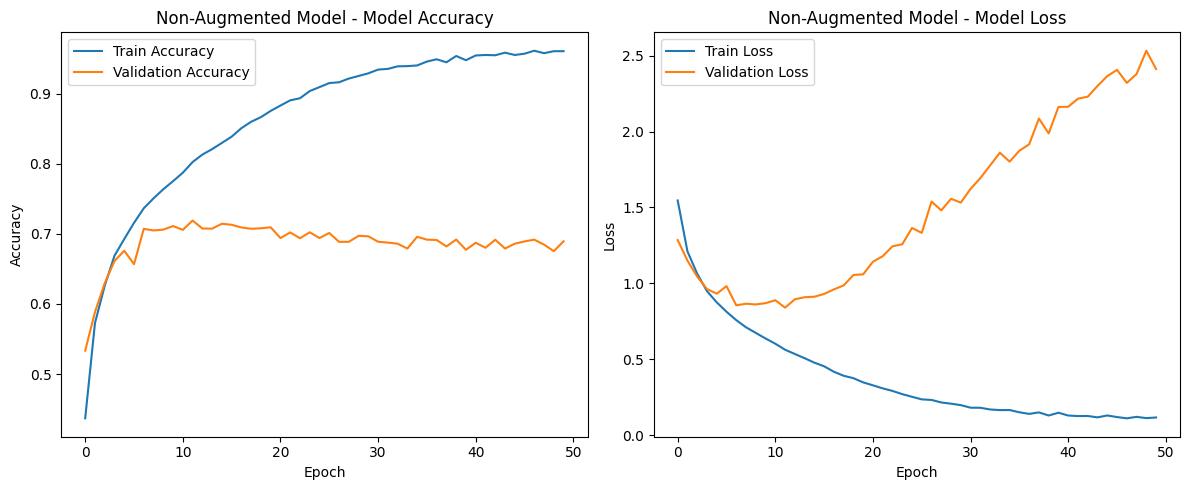

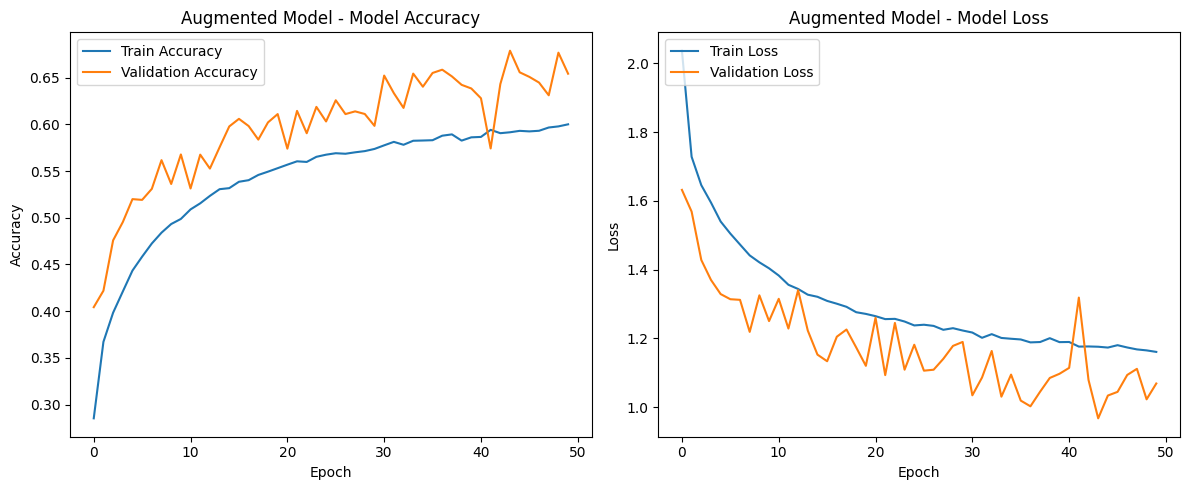

In [16]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Plot for Non-Augmented Model
plot_history(training_model, 'Non-Augmented Model')

# Plot for Augmented Model
plot_history(augmented_training_model, 'Augmented Model')

### Conclusion from Model Performance Graphs:

Based on the training and validation accuracy and loss curves for both models:

**Non-Augmented Model:**
*   **High Training Accuracy, Moderate Validation Accuracy:** The non-augmented model achieved very high training accuracy (approaching 1.0) and very low training loss. However, its validation accuracy plateaued at around 70-73% and validation loss eventually started to increase. This indicates that the model is likely **overfitting** to the training data, meaning it's memorizing the training examples rather than learning generalized features.
*   **Gap between Training and Validation:** A significant and growing divergence between the training accuracy/loss and validation accuracy/loss is a classic sign of overfitting.

**Augmented Model:**
*   **Lower Training and Validation Accuracy:** The augmented model generally shows lower training and validation accuracy compared to the non-augmented model, with its peak validation accuracy around 68-70%. This is slightly lower than the non-augmented model's peak.
*   **Smaller Gap, Slower Convergence:** The gap between its training and validation accuracy (and loss) is typically smaller than that of the non-augmented model, suggesting better generalization (less overfitting). However, it appears to converge slower or hasn't reached its full potential within the 50 epochs, possibly indicating **underfitting** or that it simply needs more training time.
*   **Validation Loss Behavior:** The validation loss for the augmented model appears more stable or shows a slower increase, implying that the augmentation is helping to prevent severe overfitting, even if overall performance is currently lower.

**Overall Summary:**
While the non-augmented model achieved a higher peak validation accuracy, it exhibited clear signs of overfitting. The augmented model, though having a slightly lower peak validation accuracy, demonstrated better generalization characteristics (less overfitting). The primary challenges for the augmented model seem to be either **underfitting** (due to potentially overly aggressive augmentation parameters making the task too difficult for the current model) or **requiring more training epochs** to fully leverage the diverse augmented data and achieve its optimal performance. The lack of normalization for the augmented data, as noted in the notebook overview, could also be a contributing factor.